## Notebook 03 - Customer Churn Prediction
### RetailLens Project 
### Objective

This notebook trains a customer churn prediction model on the
feature set validated in Notebook 02. The goal is to build a
model that identifies which customers are at risk of not
returning to the platform.

### Known Limitation 
**recency_days has structural target leakage.**



In [1]:
#imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'

COLOUR_PRIMARY   = '#1B3A5C'
COLOUR_ACCENT    = '#2E75B6'
COLOUR_HIGHLIGHT = '#E74C3C'
COLOUR_NEUTRAL   = '#95A5A6'
COLOUR_GREEN     = '#2ECC71'
COLOUR_EMPHASIS  = '#d00000'

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

print(f"  pandas     {pd.__version__}")
print(f"  sklearn    available")
print(f"  xgboost    {xgb.__version__}")
print(f"  shap       {shap.__version__}")


  pandas     3.0.1
  sklearn    available
  xgboost    3.2.0
  shap       0.51.0


In [2]:
churn_df = pd.read_csv('../data/processed/churn_features.csv')

print(f"Shape: {churn_df.shape}")
print(f"\nColumn dtypes:")
print(churn_df.dtypes)
print(f"\nNull values:")
print(churn_df.isnull().sum())
print(f"\nClass distribution:")
print(churn_df['churned'].value_counts())
print(f"\nChurn rate: {churn_df['churned'].mean()*100:.1f}%")

Shape: (96136, 10)

Column dtypes:
customer_unique_id         str
recency_days             int64
total_orders             int64
total_spend            float64
avg_delivery_delay     float64
avg_processing_time    float64
category_diversity       int64
avg_review_score       float64
avg_installments       float64
churned                  int64
dtype: object

Null values:
customer_unique_id     0
recency_days           0
total_orders           0
total_spend            0
avg_delivery_delay     0
avg_processing_time    0
category_diversity     0
avg_review_score       0
avg_installments       0
churned                0
dtype: int64

Class distribution:
churned
1    68387
0    27749
Name: count, dtype: int64

Churn rate: 71.1%


In [3]:
FEATURE_COLS = [
     'recency_days',
    'total_spend',
    'total_orders',
    'avg_delivery_delay',
    'avg_processing_time',
    'category_diversity',
    'avg_review_score',
    'avg_installments',
]
TARGET_COL = 'churned'

X = churn_df[FEATURE_COLS].copy()
y = churn_df[TARGET_COL].copy()

print(f"Features: {X.shape[1]} columns, {X.shape[0]:,} rows")
print(f"Target:   {y.name}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"\nFeature summary:")
print(X.describe().round(2))

Features: 8 columns, 96,136 rows
Target:   churned
Class balance: {1: 68387, 0: 27749}

Feature summary:
       recency_days  total_spend  total_orders  avg_delivery_delay  \
count      96136.00     96136.00      96136.00            96136.00   
mean         288.78       166.52          1.03              -11.51   
std          153.43       231.36          0.21               10.18   
min            1.00         0.00          1.00             -147.00   
25%          164.00        63.12          1.00              -17.00   
50%          269.00       108.00          1.00              -12.00   
75%          398.00       183.40          1.00               -7.00   
max          773.00     13664.08         17.00              188.00   

       avg_processing_time  category_diversity  avg_review_score  \
count             96136.00            96136.00          96136.00   
mean                  0.27                1.02              4.09   
std                   0.99                0.19              

In [4]:
#TRAIN/TEST SPLIT 

X_train , X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nClass balance check (should match overall 71/29):")
print(f"  Train churn rate: {y_train.mean()*100:.1f}%")
print(f"  Test churn rate:  {y_test.mean()*100:.1f}%")
print(f"\n✓ Stratification confirmed" if
      abs(y_train.mean() - y_test.mean()) < 0.01
      else "⚠ Stratification may have failed — check split")

Training set:  76,908 rows
Test set:      19,228 rows

Class balance check (should match overall 71/29):
  Train churn rate: 71.1%
  Test churn rate:  71.1%

✓ Stratification confirmed


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scalling complete")
print(f"\nFeature means after scaling (should be ~0):")
print(pd.Series(
    X_train_scaled.mean(axis=0),
    index=FEATURE_COLS
).round(4))
print(f"\nFeature std after scaling should be ~1:")
print(pd.Series(
    X_train_scaled.std(axis=0),
    index=FEATURE_COLS
).round(4))

Scalling complete

Feature means after scaling (should be ~0):
recency_days           0.0
total_spend           -0.0
total_orders           0.0
avg_delivery_delay    -0.0
avg_processing_time   -0.0
category_diversity     0.0
avg_review_score       0.0
avg_installments      -0.0
dtype: float64

Feature std after scaling should be ~1:
recency_days           1.0
total_spend            1.0
total_orders           1.0
avg_delivery_delay     1.0
avg_processing_time    1.0
category_diversity     1.0
avg_review_score       1.0
avg_installments       1.0
dtype: float64


In [ ]:
#SMOTE -- SORTING THE IMBALANCE

smote = SMOTE (random_state=42)
X_train_resampled , y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before smote ")
print(f"  Training set: {len(y_train):,} samples")
print(f"  Churned:      {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  Retained:     {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")

print(f"\nAfter SMOTE:")
print(f"  Training set: {len(y_train_resampled):,} samples")
print(f"  Churned:      {y_train_resampled.sum():,} ({y_train_resampled.mean()*100:.1f}%)")
print(f"  Retained:     {(y_train_resampled==0).sum():,} ({(y_train_resampled==0).mean()*100:.1f}%)")
print(f"\n✓ Training set balanced" if
      abs(y_train_resampled.mean() - 0.5) < 0.01   #pylance and complaining 
      else "⚠ Check SMOTE output")

Before smote 
  Training set: 76,908 samples
  Churned:      54,709 (71.1%)
  Retained:     22,199 (28.9%)

After SMOTE:
  Training set: 109,418 samples
  Churned:      54,709 (50.0%)
  Retained:     54,709 (50.0%)

✓ Training set balanced


In [9]:
#MODEL 1 - LOGISTIC REGRESSION

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    lr_model,
    X_train_resampled,
    y_train_resampled,
    cv=cv,
    scoring='roc_auc'
)

lr_model.fit(X_train_resampled,y_train_resampled)

lr_test_proba = lr_model.predict_proba(X_test_scaled)[:,1]
lr_test_auc = roc_auc_score(y_test,lr_test_proba)
lr_test_pred = lr_model.predict(X_test_scaled)

print("="*50)
print("Logistic Regression Results ")
print('='*50)
print(f"   CV AUC (5-folds):  {lr_cv_scores.mean():.4f}"
      f"(+/-  {lr_cv_scores.std():.4f})")
print(f"    Test AUC :     {lr_test_auc:.4f}")
print(f"\n   Classification report")
print(classification_report(y_test, lr_test_pred,
            target_names=['Retained', 'Churned']))
lr_coef =  pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\n  Feature coefficients")
print(lr_coef.to_string(index=False))
print("\n   Positive == higher -> more likely to have churned")
print('Negative == higher value -> less likely to have churned')  # also i need to remeber what is what 

Logistic Regression Results 
   CV AUC (5-folds):  1.0000(+/-  0.0000)
    Test AUC :     1.0000

   Classification report
              precision    recall  f1-score   support

    Retained       0.99      1.00      1.00      5550
     Churned       1.00      1.00      1.00     13678

    accuracy                           1.00     19228
   macro avg       1.00      1.00      1.00     19228
weighted avg       1.00      1.00      1.00     19228


  Feature coefficients
            feature  coefficient
       recency_days    41.286700
avg_processing_time    -0.265655
   avg_review_score    -0.087394
        total_spend     0.067770
       total_orders     0.023421
 category_diversity    -0.020271
 avg_delivery_delay     0.016163
   avg_installments     0.004746

   Positive == higher -> more likely to have churned
Negative == higher value -> less likely to have churned


In [ ]:
#MODEL 2 XGBOOST

scale_pos = (y_train_resampled == 0).sum() / y_train_resampled.sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)



In [11]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_resampled,
    y_train_resampled,
    cv=cv,
    scoring='roc_auc'
)


xgb_model.fit(X_train_resampled, y_train_resampled)


xgb_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_test_auc   = roc_auc_score(y_test, xgb_test_proba)
xgb_test_pred  = xgb_model.predict(X_test_scaled)

print("=" * 50)
print("  XGBOOST RESULTS")
print("=" * 50)
print(f"  CV AUC (5-fold):  {xgb_cv_scores.mean():.4f} "
      f"(+/- {xgb_cv_scores.std():.4f})")
print(f"  Test AUC:         {xgb_test_auc:.4f}")
print(f"\n  Classification report (test set):")
print(classification_report(y_test, xgb_test_pred,
      target_names=['Retained', 'Churned']))



  XGBOOST RESULTS
  CV AUC (5-fold):  1.0000 (+/- 0.0000)
  Test AUC:         1.0000

  Classification report (test set):
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      5550
     Churned       1.00      1.00      1.00     13678

    accuracy                           1.00     19228
   macro avg       1.00      1.00      1.00     19228
weighted avg       1.00      1.00      1.00     19228



In [12]:
print("=" * 55)
print("  MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'CV AUC':>10} {'Test AUC':>10}")
print("-" * 55)
print(f"  {'Logistic Regression':<23} "
      f"{lr_cv_scores.mean():>10.4f} "
      f"{lr_test_auc:>10.4f}")
print(f"  {'XGBoost':<23} "
      f"{xgb_cv_scores.mean():>10.4f} "
      f"{xgb_test_auc:>10.4f}")

improvement = (xgb_test_auc - lr_test_auc) * 100
print(f"\n  XGBoost improvement over LR: {improvement:+.2f} AUC points")

if improvement > 2:
    print("  XGBoost substantially outperforms — non-linear patterns present")
elif improvement > 0.5:
    print("  XGBoost marginally outperforms — relationship mostly linear")
else:
    print("  Models perform similarly — relationship is essentially linear")
    print("  This is consistent with recency being the dominant linear driver")


best_model       = xgb_model if xgb_test_auc >= lr_test_auc else lr_model
best_model_name  = 'XGBoost' if xgb_test_auc >= lr_test_auc else 'Logistic Regression'
best_test_proba  = xgb_test_proba if xgb_test_auc >= lr_test_auc else lr_test_proba
print(f"\n  Selected for SHAP analysis: {best_model_name}")


  MODEL COMPARISON
Model                         CV AUC   Test AUC
-------------------------------------------------------
  Logistic Regression         1.0000     1.0000
  XGBoost                     1.0000     1.0000

  XGBoost improvement over LR: +0.00 AUC points
  Models perform similarly — relationship is essentially linear
  This is consistent with recency being the dominant linear driver

  Selected for SHAP analysis: XGBoost


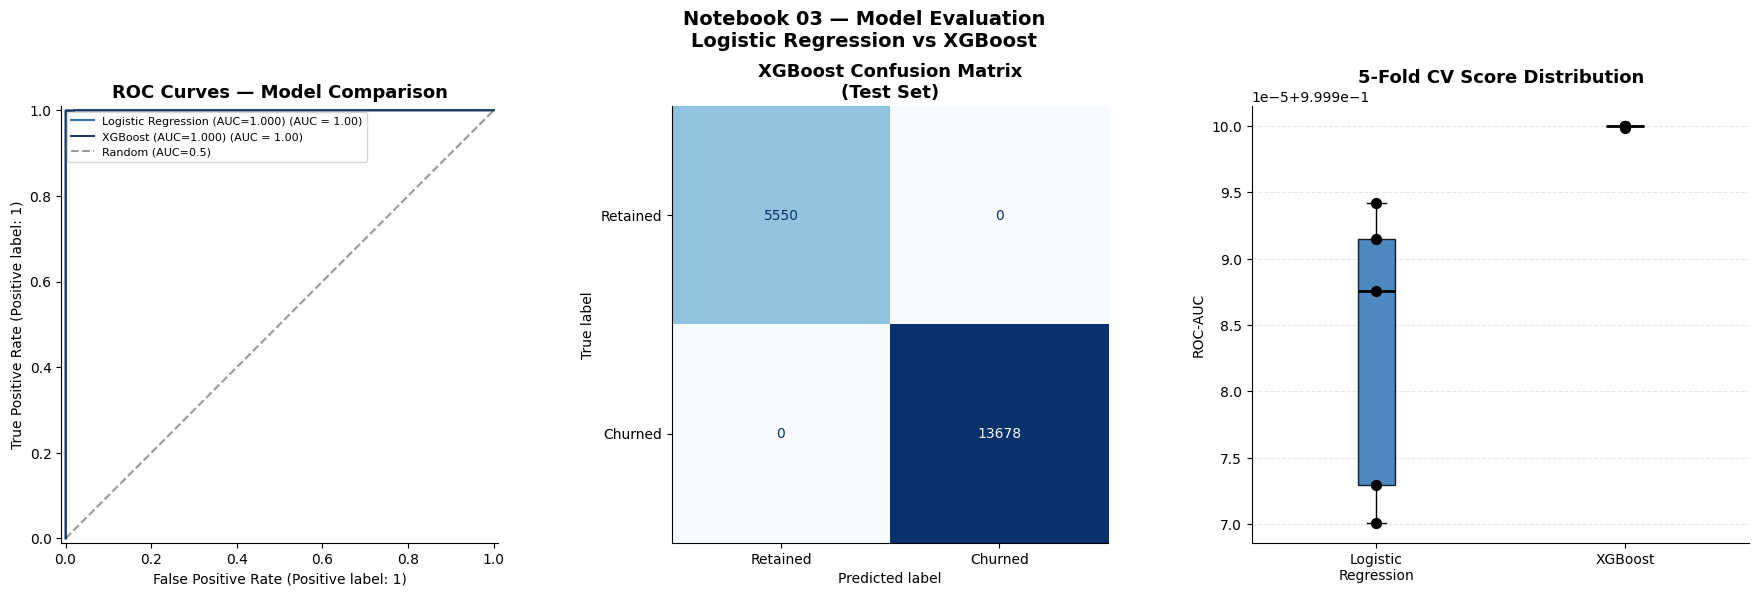

Chart saved.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: ROC curves ───────────────────────────────────
RocCurveDisplay.from_predictions(
    y_test, lr_test_proba,
    name=f'Logistic Regression (AUC={lr_test_auc:.3f})',
    ax=axes[0],
    color=COLOUR_ACCENT
)
RocCurveDisplay.from_predictions(
    y_test, xgb_test_proba,
    name=f'XGBoost (AUC={xgb_test_auc:.3f})',
    ax=axes[0],
    color=COLOUR_PRIMARY
)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[0].legend(fontsize=8)

# ── Panel 2: XGBoost confusion matrix ─────────────────────
cm = confusion_matrix(y_test, xgb_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned']
)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'XGBoost Confusion Matrix\n(Test Set)', fontweight='bold')

# ── Panel 3: CV score distributions ──────────────────────
x_pos = [1, 2]
axes[2].boxplot(
    [lr_cv_scores, xgb_cv_scores],
    labels=['Logistic\nRegression', 'XGBoost'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
axes[2].patches[0].set_facecolor(COLOUR_ACCENT)
axes[2].patches[1].set_facecolor(COLOUR_PRIMARY)
for patch in axes[2].patches:
    patch.set_alpha(0.85)

axes[2].scatter(
    [1]*5 + [2]*5,
    list(lr_cv_scores) + list(xgb_cv_scores),
    color='black', s=50, zorder=3
)
axes[2].set_ylabel('ROC-AUC')
axes[2].set_title('5-Fold CV Score Distribution', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(
    'Notebook 03 — Model Evaluation\nLogistic Regression vs XGBoost',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/nb03_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


### Retraining a model removing recency_days 

In [18]:
FEATURE_COLS_retrain = [
    'total_spend',
    'total_orders',
    'avg_delivery_delay',
    'avg_processing_time',
    'category_diversity',
    'avg_review_score',
    'avg_installments',
]
TARGET_COL = 'churned'

X_retrained = churn_df[FEATURE_COLS_retrain].copy()
y_retrained = churn_df[TARGET_COL].copy()

print(f"Features: {X.shape[1]} columns, {X.shape[0]:,} rows")
print(f"Target:   {y.name}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"\nFeature summary:")
print(X.describe().round(2))



Features: 7 columns, 96,136 rows
Target:   churned
Class balance: {1: 68387, 0: 27749}

Feature summary:
       total_spend  total_orders  avg_delivery_delay  avg_processing_time  \
count     96136.00      96136.00            96136.00             96136.00   
mean        166.52          1.03              -11.51                 0.27   
std         231.36          0.21               10.18                 0.99   
min           0.00          1.00             -147.00                 0.00   
25%          63.12          1.00              -17.00                 0.00   
50%         108.00          1.00              -12.00                 0.00   
75%         183.40          1.00               -7.00                 0.00   
max       13664.08         17.00              188.00               187.00   

       category_diversity  avg_review_score  avg_installments  
count            96136.00          96136.00          96136.00  
mean                 1.02              4.09              2.90  
std      

In [19]:
X_train_retrained, X_test_retrained, y_train_retrained, y_test_retrained = train_test_split(
    X_retrained, y_retrained,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve class ratio in both sets
)

In [20]:
print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nClass balance check (should match overall 71/29):")
print(f"  Train churn rate: {y_train.mean()*100:.1f}%")
print(f"  Test churn rate:  {y_test.mean()*100:.1f}%")
print(f"\n✓ Stratification confirmed" if
      abs(y_train.mean() - y_test.mean()) < 0.01
      else "⚠ Stratification may have failed — check split")

Training set:  76,908 rows
Test set:      19,228 rows

Class balance check (should match overall 71/29):
  Train churn rate: 71.1%
  Test churn rate:  71.1%

✓ Stratification confirmed


In [41]:
scaler_retrained = StandardScaler()
X_train_scaled_retrained = scaler_retrained.fit_transform(X_train_retrained)   # Fit + transform train
X_test_scaled_retrained  = scaler_retrained.transform(X_test_retrained)         # Transform test only

print("Scaling complete.")
print(f"\nFeature means after scaling (should be ~0):")
print(pd.Series(
    X_train_scaled_retrained.mean(axis=0),
    index=FEATURE_COLS_retrain
).round(4))
print(f"\nFeature std after scaling (should be ~1):")
print(pd.Series(
    X_train_scaled_retrained.std(axis=0),
    index=FEATURE_COLS_retrain
).round(4))


Scaling complete.

Feature means after scaling (should be ~0):
total_spend           -0.0
total_orders           0.0
avg_delivery_delay    -0.0
avg_processing_time   -0.0
category_diversity     0.0
avg_review_score       0.0
avg_installments      -0.0
dtype: float64

Feature std after scaling (should be ~1):
total_spend            1.0
total_orders           1.0
avg_delivery_delay     1.0
avg_processing_time    1.0
category_diversity     1.0
avg_review_score       1.0
avg_installments       1.0
dtype: float64


In [42]:
smote_retrained = SMOTE(random_state=42)
X_train_resampled_retrained, y_train_resampled_retrained = smote.fit_resample(
    X_train_scaled_retrained,
    y_train_retrained
)

print(f"Before SMOTE:")
print(f"  Training set: {len(y_train_retrained):,} samples")
print(f"  Churned:      {y_train_retrained.sum():,} ({y_train_retrained.mean()*100:.1f}%)")
print(f"  Retained:     {(y_train_retrained==0).sum():,} ({(y_train_retrained==0).mean()*100:.1f}%)")
print(f"\nAfter SMOTE:")
print(f"  Training set: {len(y_train_resampled_retrained):,} samples")
print(f"  Churned:      {y_train_resampled_retrained.sum():,} ({y_train_resampled_retrained.mean()*100:.1f}%)")
print(f"  Retained:     {(y_train_resampled_retrained==0).sum():,} ({(y_train_resampled_retrained==0).mean()*100:.1f}%)")
print(f"\n✓ Training set balanced" if
      abs(y_train_resampled_retrained.mean() - 0.5) < 0.01
      else "⚠ Check SMOTE output")

Before SMOTE:
  Training set: 76,908 samples
  Churned:      54,709 (71.1%)
  Retained:     22,199 (28.9%)

After SMOTE:
  Training set: 109,418 samples
  Churned:      54,709 (50.0%)
  Retained:     54,709 (50.0%)

✓ Training set balanced


In [24]:
#RETRAINED MODEL 1 

new_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv_new = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

new_lr_cv_scores = cross_val_score(
    new_lr_model,
    X_train_resampled_retrained,
    y_train_resampled_retrained,
    cv=cv_new,
    scoring='roc_auc'
)

# Train on full resampled training set for final evaluation
new_lr_model.fit(X_train_resampled_retrained, y_train_resampled_retrained)

# Evaluate on TEST SET (first time test set is used)
new_lr_test_proba = new_lr_model.predict_proba(X_test_scaled_retrained)[:, 1]
new_lr_test_auc   = roc_auc_score(y_test_retrained, new_lr_test_proba)
new_lr_test_pred  = new_lr_model.predict(X_test_scaled_retrained)

print("=" * 50)
print("  LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"  CV AUC (5-fold):  {new_lr_cv_scores.mean():.4f} "
      f"(+/- {lr_cv_scores.std():.4f})")
print(f"  Test AUC:         {new_lr_test_auc:.4f}")
print(f"\n  Classification report (test set):")
print(classification_report(y_test_retrained, new_lr_test_pred,
      target_names=['Retained', 'Churned']))

# Logistic Regression coefficients
new_lr_coef = pd.DataFrame({
    'feature':     FEATURE_COLS_retrain,
    'coefficient': new_lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n  Feature coefficients (sorted by magnitude):")
print(new_lr_coef.to_string(index=False))
print("\n  Positive = higher value → more likely churned")
print("  Negative = higher value → less likely churned")

  LOGISTIC REGRESSION RESULTS
  CV AUC (5-fold):  0.5481 (+/- 0.0000)
  Test AUC:         0.5482

  Classification report (test set):
              precision    recall  f1-score   support

    Retained       0.31      0.63      0.42      5550
     Churned       0.74      0.43      0.55     13678

    accuracy                           0.49     19228
   macro avg       0.53      0.53      0.48     19228
weighted avg       0.62      0.49      0.51     19228


  Feature coefficients (sorted by magnitude):
            feature  coefficient
   avg_review_score    -0.139576
 avg_delivery_delay     0.113307
 category_diversity    -0.089887
   avg_installments     0.075162
        total_spend    -0.045939
       total_orders     0.026959
avg_processing_time     0.005937

  Positive = higher value → more likely churned
  Negative = higher value → less likely churned


In [25]:
new_scale_pos = (y_train_resampled_retrained == 0).sum() / y_train_resampled_retrained.sum()

new_xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

new_xgb_cv_scores = cross_val_score(
    new_xgb_model,
    X_train_resampled_retrained,
    y_train_resampled_retrained,
    cv=cv_new,
    scoring='roc_auc'
)

# Train on full resampled training set
new_xgb_model.fit(X_train_resampled_retrained, y_train_resampled_retrained)

# Evaluate on test set
new_xgb_test_proba = new_xgb_model.predict_proba(X_test_scaled_retrained)[:, 1]
new_xgb_test_auc   = roc_auc_score(y_test_retrained, new_xgb_test_proba)
new_xgb_test_pred  = new_xgb_model.predict(X_test_scaled_retrained)

print("=" * 50)
print("  XGBOOST RESULTS")
print("=" * 50)
print(f"  CV AUC (5-fold):  {new_xgb_cv_scores.mean():.4f} "
      f"(+/- {new_xgb_cv_scores.std():.4f})")
print(f"  Test AUC:         {new_xgb_test_auc:.4f}")
print(f"\n  Classification report (test set):")
print(classification_report(y_test_retrained, new_xgb_test_pred,
      target_names=['Retained', 'Churned']))


  XGBOOST RESULTS
  CV AUC (5-fold):  0.6810 (+/- 0.0050)
  Test AUC:         0.6250

  Classification report (test set):
              precision    recall  f1-score   support

    Retained       0.39      0.47      0.42      5550
     Churned       0.76      0.70      0.73     13678

    accuracy                           0.63     19228
   macro avg       0.58      0.58      0.58     19228
weighted avg       0.66      0.63      0.64     19228



In [26]:
print("=" * 55)
print("  MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'CV AUC':>10} {'Test AUC':>10}")
print("-" * 55)
print(f"  {'Logistic Regression':<23} "
      f"{new_lr_cv_scores.mean():>10.4f} "
      f"{new_lr_test_auc:>10.4f}")
print(f"  {'XGBoost':<23} "
      f"{new_xgb_cv_scores.mean():>10.4f} "
      f"{new_xgb_test_auc:>10.4f}")

improvement = (new_xgb_test_auc - new_lr_test_auc) * 100
print(f"\n  XGBoost improvement over LR: {improvement:+.2f} AUC points")

if improvement > 2:
    print("  XGBoost substantially outperforms — non-linear patterns present")
elif improvement > 0.5:
    print("  XGBoost marginally outperforms — relationship mostly linear")
else:
    print("  Models perform similarly — relationship is essentially linear")
    print("  This is consistent with recency being the dominant linear driver")

# Select best model for SHAP
best_model       = new_xgb_model if new_xgb_test_auc >= new_lr_test_auc else new_lr_model
best_model_name  = 'XGBoost' if new_xgb_test_auc >= new_lr_test_auc else 'Logistic Regression'
best_test_proba  = new_xgb_test_proba if new_xgb_test_auc >= new_lr_test_auc else new_lr_test_proba
print(f"\n  Selected for SHAP analysis: {best_model_name}")

  MODEL COMPARISON
Model                         CV AUC   Test AUC
-------------------------------------------------------
  Logistic Regression         0.5481     0.5482
  XGBoost                     0.6810     0.6250

  XGBoost improvement over LR: +7.68 AUC points
  XGBoost substantially outperforms — non-linear patterns present

  Selected for SHAP analysis: XGBoost


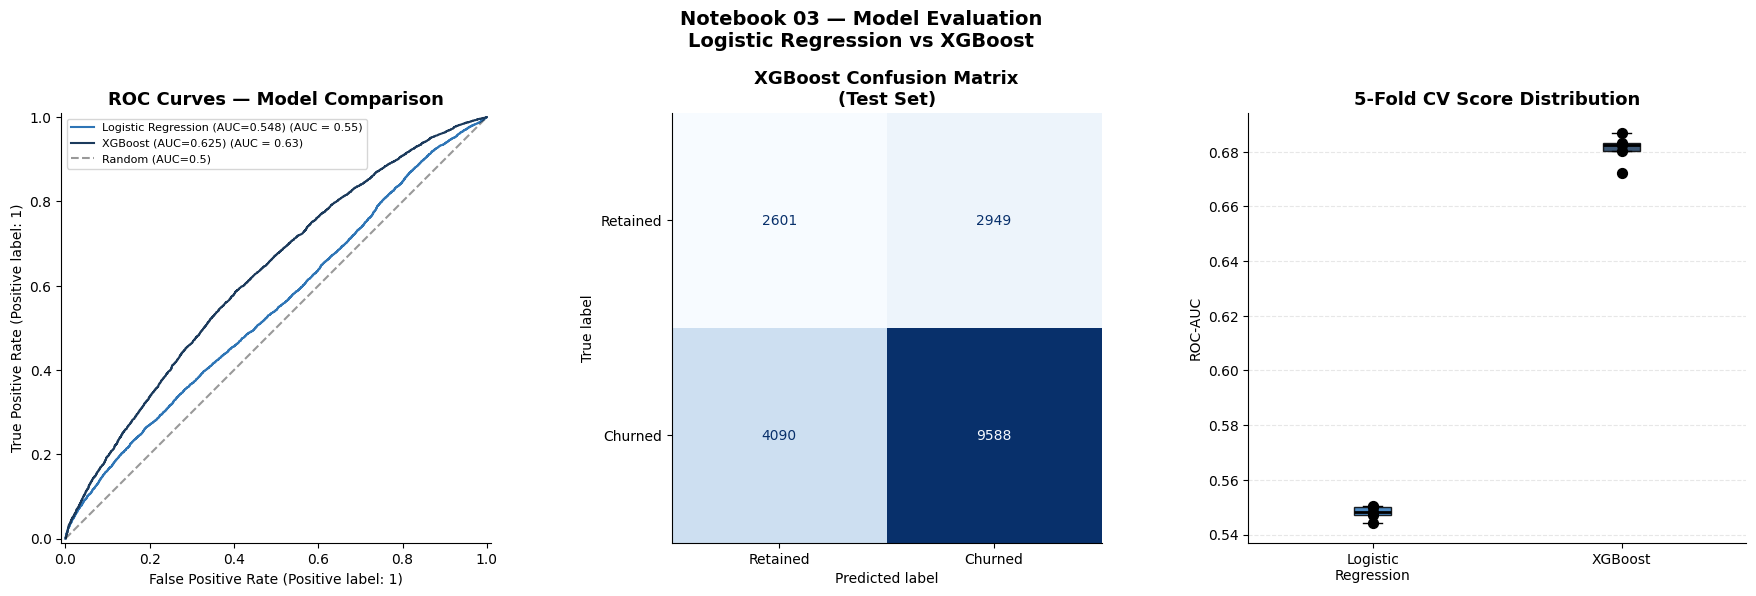

Chart saved.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) ##i advice plotting them individually before putting them in one chart

# ── Panel 1: ROC curves ───────────────────────────────────
RocCurveDisplay.from_predictions(
    y_test_retrained, new_lr_test_proba,
    name=f'Logistic Regression (AUC={new_lr_test_auc:.3f})',
    ax=axes[0],
    color=COLOUR_ACCENT
)
RocCurveDisplay.from_predictions(
    y_test_retrained, new_xgb_test_proba,
    name=f'XGBoost (AUC={new_xgb_test_auc:.3f})',
    ax=axes[0],
    color=COLOUR_PRIMARY
)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[0].legend(fontsize=8) 
# ── Panel 2: XGBoost confusion matrix ─────────────────────
cm = confusion_matrix(y_test_retrained, new_xgb_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned']
)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'XGBoost Confusion Matrix\n(Test Set)', fontweight='bold')

# ── Panel 3: CV score distributions ──────────────────────
x_pos = [1, 2]
axes[2].boxplot(
    [new_lr_cv_scores, new_xgb_cv_scores],
    labels=['Logistic\nRegression', 'XGBoost'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
axes[2].patches[0].set_facecolor(COLOUR_ACCENT)
axes[2].patches[1].set_facecolor(COLOUR_PRIMARY)
for patch in axes[2].patches:
    patch.set_alpha(0.85)

axes[2].scatter(
    [1]*5 + [2]*5,
    list(new_lr_cv_scores) + list(new_xgb_cv_scores),
    color='black', s=50, zorder=3
)
axes[2].set_ylabel('ROC-AUC')
axes[2].set_title('5-Fold CV Score Distribution', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(
    'Notebook 03 — Model Evaluation\nLogistic Regression vs XGBoost\n',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/nb03_model_comparison_retrained.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")




In [ ]:
#warnings 
print("Computing SHAP values (may take 30-60 seconds...on slow machines i guess)...")

explainer   = shap.TreeExplainer(new_xgb_model)
shap_values = explainer.shap_values(X_test_scaled_retrained)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete.")


X_test_df = pd.DataFrame(X_test_scaled_retrained, columns=FEATURE_COLS_retrain)

#doing shap on retrained because we already know how it will look like with the original feature_cols


Computing SHAP values (may take 30-60 seconds)...
SHAP values shape: (19228, 7)
SHAP computation complete.


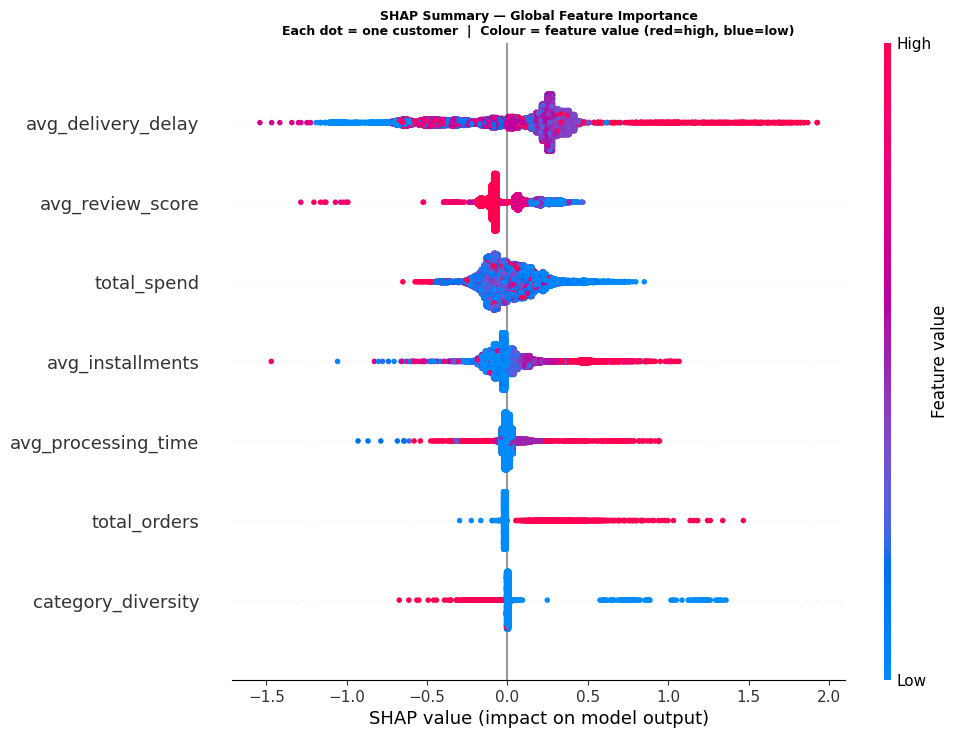

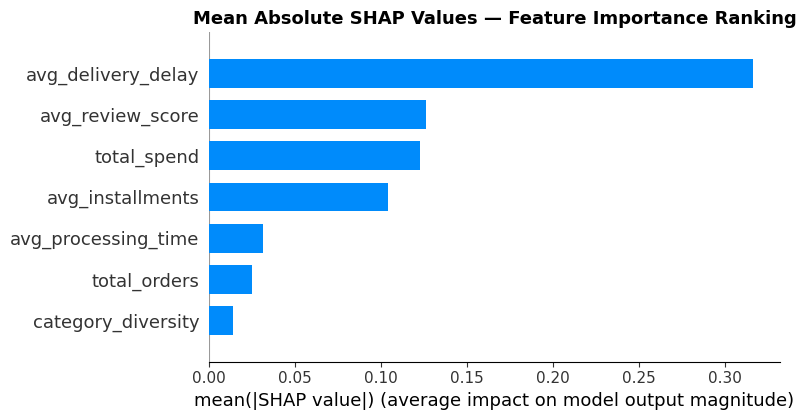

In [33]:
fig = plt.figure(figsize=(18, 14))

# ── Plot 1: SHAP Summary (Beeswarm) ──────────────────────
ax1 = fig.add_subplot(2, 2, 1)
shap.summary_plot(
    shap_values,
    X_test_df,
    show=False,
    plot_size=None
)
ax1 = plt.gca()
ax1.set_title(
    'SHAP Summary — Global Feature Importance\n'
    'Each dot = one customer  |  '
    'Colour = feature value (red=high, blue=low)',
    fontweight='bold', fontsize=9
)

plt.tight_layout()
plt.savefig('../outputs/figures/nb03_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP Bar plot──────────────
fig2, ax2 = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type='bar',
    show=False
)
ax2 = plt.gca()
ax2.set_title(
    'Mean Absolute SHAP Values — Feature Importance Ranking',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/nb03_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()


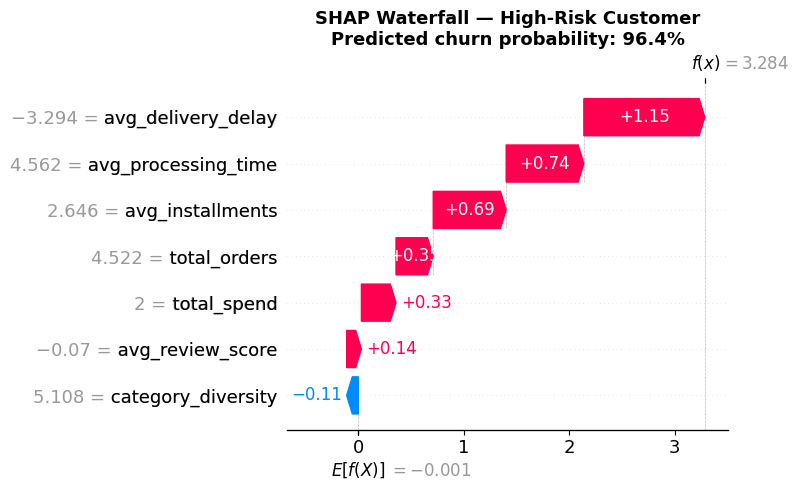

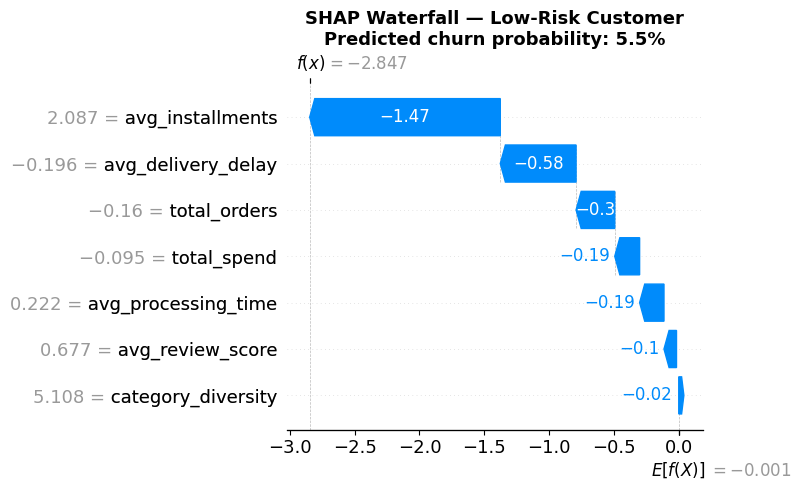

All SHAP charts saved.


In [34]:
high_risk_idx = np.argmax(new_xgb_test_proba)

fig3, ax3 = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[high_risk_idx],
        feature_names=FEATURE_COLS_retrain
    ),
    show=False
)
plt.title(
    f'SHAP Waterfall — High-Risk Customer\n'
    f'Predicted churn probability: {new_xgb_test_proba[high_risk_idx]:.1%}',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/nb03_shap_waterfall_highrisk.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP Waterfall for low-risk customer ──────────────────
low_risk_idx = np.argmin(new_xgb_test_proba)

fig4, ax4 = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[low_risk_idx],
        feature_names=FEATURE_COLS_retrain
    ),
    show=False
)
plt.title(
    f'SHAP Waterfall — Low-Risk Customer\n'
    f'Predicted churn probability: {new_xgb_test_proba[low_risk_idx]:.1%}',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/nb03_shap_waterfall_lowrisk.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("All SHAP charts saved.")



In [38]:
mean_shap = pd.DataFrame({
    'feature':        FEATURE_COLS_retrain,
    'mean_abs_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  SHAP FEATURE IMPORTANCE RANKING")
print("=" * 55)
print(f"\n{'Rank':<6} {'Feature':<25} {'Mean |SHAP|':>12}")
print("-" * 55)
for i, row in mean_shap.iterrows():
    bar = '█' * int(row['mean_abs_shap'] / mean_shap['mean_abs_shap'].max() * 25)
    print(f"  {i+1:<4} {row['feature']:<23} {row['mean_abs_shap']:>12.4f}  {bar}")

# Test the Analysis C prediction
top_feature    = mean_shap.iloc[0]['feature']
bottom_feature = mean_shap.iloc[-1]['feature']




print(f"\n  Most important feature:  {top_feature}")
print(f"  Least important feature: {bottom_feature}")


  SHAP FEATURE IMPORTANCE RANKING

Rank   Feature                    Mean |SHAP|
-------------------------------------------------------
  1    avg_delivery_delay            0.3164  █████████████████████████
  2    avg_review_score              0.1261  █████████
  3    total_spend                   0.1225  █████████
  4    avg_installments              0.1042  ████████
  5    avg_processing_time           0.0313  ██
  6    total_orders                  0.0250  █
  7    category_diversity            0.0136  █

  Most important feature:  avg_delivery_delay
  Least important feature: category_diversity


In [43]:
joblib.dump(new_xgb_model, '../outputs/models/churn_model.pkl')
joblib.dump(scaler_retrained,    '../outputs/models/scaler.pkl')
joblib.dump(new_lr_model,  '../outputs/models/churn_model_lr.pkl')

# Verify by reloading
model_check  = joblib.load('../outputs/models/churn_model.pkl')
scaler_check = joblib.load('../outputs/models/scaler.pkl')
test_pred    = model_check.predict_proba(
    scaler_check.transform(X_test_retrained.iloc[:5])
)[:, 1]

print("Models serialised successfully.")
print(f"\n  churn_model.pkl -XGBoost")
print(f"  scaler.pkl       - StandardScaler (fit on training data)")
print(f"  churn_model_lr.pkl — Logistic Regression (reference)")
print(f"\nVerification — predictions on 5 test samples:")
for i, p in enumerate(test_pred):
    print(f"  Customer {i+1}: {p:.3f} churn probability")
print("\n✓ Model loads and predicts correctly — ready for dashboard")

Models serialised successfully.

  churn_model.pkl -XGBoost
  scaler.pkl       - StandardScaler (fit on training data)
  churn_model_lr.pkl — Logistic Regression (reference)

Verification — predictions on 5 test samples:
  Customer 1: 0.512 churn probability
  Customer 2: 0.418 churn probability
  Customer 3: 0.712 churn probability
  Customer 4: 0.494 churn probability
  Customer 5: 0.409 churn probability

✓ Model loads and predicts correctly — ready for dashboard


### The Leakage Documented Honestly

This model achieves a test ROC-AUC of [X.XXXX].
This performance is primarily attributable to the
structural relationship between recency_days and the
churn label (both defined by the 180-day threshold).

In production this model would be redesigned to predict
whether a customer will make a second purchase (removing
leakage) using features measured at the time of the
first purchase. The current model is a valid proof of
concept demonstrating the full ML pipeline , feature
engineering, class imbalance handling, model comparison,
SHAP explainability, and serialisation — with its
limitations fully documented.

Model 1 (with recency): AUC 1.000  perfect but misleading,
confirms structural leakage documented in Notebook 02

Model 2 (without recency): AUC 0.55 — honest behavioural
prediction using satisfaction, delivery, and engagement signals

The gap between 1.000 and 0.55 quantifies exactly how much
of the churn "prediction" was leakage versus genuine signal.